# Домашнее задание №3: Классификация 128x128 + U-Net c бэкбоном

### Датасеты

- Классификация: Tiny ImageNet-200 из семинара 2.
    - Набор данных необходимо взять из второго семинара и привести к разрешению 128x128
    - Разрешение: приведите вход к 128×128 (ресайз/кроп по вашему выбору, главное — корректно описать в отчёте).
- Сегментация: MOON_SEGMENTATION_BINARY из семинара 3.
    - Структура: `images/render/*.png` — входы, `images/ground/*.png` — бинарные маски.


In [1]:
# загрузка библиотек
import os
import random
import numpy as np
import pandas as pd

from PIL import Image
from torch.utils.data import Dataset, DataLoader

from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import transforms, models
from tqdm import tqdm

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

torch.set_num_threads(7)  

## Часть 1. Классификатор 128×128

- Требования к модели:
    - Своя архитектура (разрешается вдохновляться CNN-идеями: Conv-BN-ReLU, блоки с даунсемплингом, GAP и т.д.).
    - Ограничение на параметризованность: не более ~5M параметров.
    - Вход: 128×128×3.
    - Можно выбрать любое количество классов для обучения!
- Обучение:
    - Трен/вал сплит: выберите собственную стратификацию.
    - Аугментации: разумные (кроп, флипы, color jitter и т.д.), кратко опишите в отчёте.
- Что сдаём по части 1:
    - График/лог обучения (loss/accuracy по эпохам) и итоговые метрики на валидации.
    - Чекпоинт модели (по возможности) или веса/ссылка.


In [7]:
class TinyImageNetDataset(Dataset):
    def __init__(self, root_dir, class_list, split='train', transform=None,
                 custom_samples=None):
        """
        root_dir: путь до папки tiny-imagenet-200
        class_list: список индексов классов из wnids.txt
        split: 'train', 'val', 'test' или 'custom'
        transform: аугментации
        custom_samples: список образцов [(path, label), ...], т.к. хотим вручную задать выборку с помощью простой случайной классификации потом
        """
        self.root_dir = root_dir
        self.class_list = class_list
        self.split = split
        self.transform = transform

        with open(os.path.join(root_dir, 'wnids.txt'), 'r') as f:
            all_class_names = [line.strip() for line in f]

        self.class_names = [all_class_names[idx] for idx in self.class_list]
        self.class_to_idx = {name: i for i, name in enumerate(self.class_names)}

        class_map = {}
        with open(os.path.join(root_dir, 'words.txt'), 'r') as f:
            for line in f:
                tokens = line.strip().split('\t')
                wnid, name = tokens[0], ' '.join(tokens[1:])
                class_map[wnid] = name

        self.real_class_names = [class_map[c] for c in self.class_names]

        if custom_samples is not None:
            self.samples = custom_samples
            return  

        self.samples = []

        if split == 'train':
            train_dir = os.path.join(root_dir, 'train')
            for cls in os.listdir(train_dir):
                if cls not in self.class_names:
                    continue
                img_dir = os.path.join(train_dir, cls, 'images')
                if not os.path.exists(img_dir):
                    continue
                for img_name in os.listdir(img_dir):
                    img_path = os.path.join(img_dir, img_name)
                    label = self.class_to_idx[cls]
                    self.samples.append((img_path, label))

        elif split == 'val':
            val_dir = os.path.join(root_dir, 'val', 'images')
            anno_path = os.path.join(root_dir, 'val', 'val_annotations.txt')

            label_map = {}
            with open(anno_path, 'r') as f:
                for line in f:
                    img_name, cls, *_ = line.strip().split('\t')
                    label_map[img_name] = cls

            for img_name in os.listdir(val_dir):
                cls = label_map.get(img_name)
                if cls in self.class_names:
                    img_path = os.path.join(val_dir, img_name)
                    label = self.class_to_idx[cls]
                    self.samples.append((img_path, label))

        else:  # split == 'test'
            test_dir = os.path.join(root_dir, 'test', 'images')
            for img_name in os.listdir(test_dir):
                img_path = os.path.join(test_dir, img_name)
                self.samples.append((img_path, -1))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label


Испольуемые изображения приведем в расширение 128 x 128 и добавим к ним аугментации. 
Применим следующие преобразования:
- `RandomResizedCrop(128, scale=(0.7, 1.0))` - случайно вырежем участок изображения размером от 70% до 100% исходного и масштабирует его к 128×128 &#8594; делает модель устойчивой к изменениям масштаба и смещению объекта 
- `RandomHorizontalFlip()` - зеркально отразим изображение по горизонтали 
- `ColorJitter(0.2, 0.2, 0.2)` - изменим случайным образом яркость, контраст и насыщенность &#8594; это делает модлеь более устойчивость к разным условиям освещения
- `RandomRotation(10)` - поворачиваем картинку на случайный угол до ±10° &#8594; это делает модель не зависящей от ориентации объекта
- `Normalize(mean, std)` - стандартизируем изображение по каналам (как и во втором домашнем задании)


Также как и во втором домашнем задании для работы выбрем 5 классо случайным образом.

В качестве метода стратификации была выбрана прстая случайная стратификация. Т.е. в отличие от прошлого задания для обучения модели будет использовать только train датасет. Из него возьмем поднабор для валидации.

In [ ]:
# Аугментации
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(128, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2,0.2,0.2),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((128, 128)),   
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


root = "tiny-imagenet-200/tiny-imagenet-200"

# Случайный выбор 5 классов
class_list = random.sample(range(200), 5) 
train_dataset = TinyImageNetDataset(root, class_list, split='train', transform=train_transform)
all_samples = train_dataset.samples

print(f" Всего образцов: {len(all_samples)}")

random.seed(42)
all_samples_copy = all_samples.copy()
random.shuffle(all_samples_copy)

val_fraction = 0.2
split_idx = int(len(all_samples_copy) * (1 - val_fraction))
train_split_random = all_samples_copy[:split_idx]
val_split_random = all_samples_copy[split_idx:]

print(f" Случайное разделение:")
print(f"   Train: {len(train_split_random)} образцов")
print(f"   Val: {len(val_split_random)} образцов")

def analyze_class_distribution(samples, name):
    labels = [label for _, label in samples]
    class_counts = Counter(labels)
    print(f" {name} - распределение классов:")
    print(f"   Минимум: {min(class_counts.values())}")
    print(f"   Максимум: {max(class_counts.values())}")
    print(f"   Среднее: {np.mean(list(class_counts.values())):.1f}")
    print(f"   Стандартное отклонение: {np.std(list(class_counts.values())):.1f}")

analyze_class_distribution(train_split_random, "Случайное train")
analyze_class_distribution(val_split_random, "Случайное val")

train_dataset = TinyImageNetDataset(
    root_dir = root,
    class_list = class_list,
    split = 'train',
    transform = train_transform,
    custom_samples = train_split_random
)

val_dataset = TinyImageNetDataset(
    root_dir = root,
    class_list = class_list,
    split = 'train', # изображения для валидации также берем из train датасета 
    transform = val_transform,
    custom_samples = val_split_random
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0)

print(f"\nTrain size: {len(train_dataset)}")
print(f"Val size: {len(val_dataset)}")
print(f"Количество классов: {len(train_dataset.class_names)}")
print("Названия классов:")
for i in range(len(class_list)):
    print(f" ({i}) " + train_dataset.real_class_names[i])

 Всего образцов: 2500
 Случайное разделение:
   Train: 2000 образцов
   Val: 500 образцов
 Случайное train - распределение классов:
   Минимум: 388
   Максимум: 408
   Среднее: 400.0
   Стандартное отклонение: 7.7
 Случайное val - распределение классов:
   Минимум: 92
   Максимум: 112
   Среднее: 100.0
   Стандартное отклонение: 7.7

Train size: 2000
Val size: 500
Количество классов: 5
Названия классов:
 (0) desk
 (1) birdhouse
 (2) dugong, Dugong dugon
 (3) brain coral
 (4) thatch, thatched roof


Для обучения создам собственную архитектуру следующего вида:

```
Input: 128×128×3
↓
ConvBlock(3→64)           # 128×128×64
↓
ConvBlock(64→128, stride=2) # 64×64×128
↓
ConvBlock(128→128)         # 64×64×128
↓
ConvBlock(128→256, stride=2) # 32×32×256
↓
ConvBlock(256→256)         # 32×32×256
↓
ConvBlock(256→512, stride=2) # 16×16×512
↓
ConvBlock(512→512)         # 16×16×512
↓
Global Average Pooling      # 1×1×512
↓
Flatten → FC(512→num_classes)
↓
Output: class probabilities
```

Модель принимает изображения размера 128×128×3 и состоит из семи ConvBlock-блоков вида Conv2d → BatchNorm → ReLU, с даунсемплингом через stride = 2 каждые два блока. Сначала блоки увеличивают количество каналов с 3 до 64, затем до 128, после чего до 256 и, в конце до 512, постепенно уменьшая пространственные размеры карты признаков с 128×128 до 16×16. После последнего блока применяется Global Average Pooling, превращающий 16×16×512 в вектор из 512 признаков.

In [ ]:
class ConvBlock(nn.Module):
    """Базовый блок: Conv2d → BN → ReLU"""
    def __init__(self, in_ch, out_ch, down=False):
        super().__init__()
        stride = 2 if down else 1
        self.conv = nn.Conv2d(in_ch, out_ch, 3, stride = stride, padding = 1, bias = False)
        self.bn = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.bn(self.conv(x)))

class MyTinyConvNet(nn.Module):
    def __init__(self, num_classes = 5):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3, 64),          # 128x128 → 128x128
            ConvBlock(64, 128, down=True),  # 128x128 → 64x64
            ConvBlock(128, 128),       # 64x64 → 64x64
            ConvBlock(128, 256, down=True), # 64x64 → 32x32
            ConvBlock(256, 256),       # 32x32 → 32x32
            ConvBlock(256, 512, down=True), # 32x32 → 16x16
            ConvBlock(512, 512),       # 16x16 → 16x16
        )
        self.gap = nn.AdaptiveAvgPool2d(1)  # 16x16 → 1x1
        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x).view(x.size(0), -1)
        return self.fc(x)

# Проверка количества параметров
model = MyTinyConvNet(num_classes = 5)
print('Количество параметров модели: ', sum(p.numel() for p in model.parameters()))

Количество параметров модели:  4652869


По аналогии со вторим домашним заданием сделаем функции для обучения и оценки качества модели.

In [ ]:
def train_model(model, train_loader, val_loader, optimizer, criterion, device='cpu', num_epochs=20):
    """
    Функция для обучения модели на несколько эпох с вычислением train/val loss и accuracy.

    Args:
        model: модель для обучения
        train_loader: DataLoader с тренировочными данными
        val_loader: DataLoader с тестовыми данными
        optimizer: оптимизатор
        criterion: функция потерь
        device: устройство (cpu/cuda)
        num_epochs: количество эпох

    Returns:
    history = {
        train_losses: список средних потерь на train
        train_acc_list: список точностей на train
        val_losses: список средних потерь на validation
        val_acc_list: список точностей на validation
        }
    """
    model.to(device)
    
    train_losses, train_acc_list = [], []
    val_losses, val_acc_list = [], []

    best_val_acc = 0.0

    for epoch in range(num_epochs):

        # Train
        model.train()
        running_loss = 0.0
        correct, total = 0, 0

        train_iter = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", leave=False)
        for inputs, labels in train_iter:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            train_iter.set_postfix(
                batch_loss=loss.item(), 
                acc=100. * correct / total
            )

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = 100. * correct / total
        train_losses.append(train_loss)
        train_acc_list.append(train_acc)

        # Валидация
        model.eval()
        val_running_loss = 0.0
        correct, total = 0, 0

        val_iter = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]  ", leave=False)
        with torch.no_grad():
            for inputs, labels in val_iter:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * inputs.size(0)

                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

                val_iter.set_postfix(
                    batch_loss=loss.item(),
                    acc=100. * correct / total
                )

        val_loss = val_running_loss / len(val_loader.dataset)
        val_acc = 100. * correct / total
        val_losses.append(val_loss)
        val_acc_list.append(val_acc)

        # Логи обучения
        print(f'Epoch [{epoch+1}/{num_epochs}] '
              f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | '
              f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%')

        # Сохраняем лучшую модель
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'best_model.pth')
            print(f"\tСохранена лучшая модель с точностью {val_acc:.2f}%")

    return {
        'train_loss' : train_losses,
        'train_acc' : train_acc_list,
        'val_loss': val_losses,
        'val_acc' : val_acc_list
    }


In [19]:
def plot_training_history(history):

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    ax1.plot(history['train_loss'], label='Train Loss', color='blue')
    ax1.plot(history['val_loss'], label='Validation Loss', color='red')
    ax1.set_title('Training and Validation Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)
    
    ax2.plot(history['train_acc'], label='Train Accuracy', color='blue')
    ax2.plot(history['val_acc'], label='Validation Accuracy', color='red')
    ax2.set_title('Training and Validation Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

In [20]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


In [21]:
model = MyTinyConvNet(num_classes = 5)
optimizer = torch.optim.SGD(model.parameters(), lr = 0.001) 
criterion = nn.CrossEntropyLoss()  
history = train_model(model, 
                      train_loader, 
                      val_loader, 
                      optimizer, 
                      criterion, 
                      device = device, 
                      num_epochs = 20)

Epoch [1/20] Train Loss: 1.4087 | Train Acc: 38.75% | Val Loss: 1.3033 | Val Acc: 45.40%
	Сохранена лучшая модель с точностью 45.40%


Epoch [2/20] Train Loss: 1.2561 | Train Acc: 47.80% | Val Loss: 1.2328 | Val Acc: 49.00%
	Сохранена лучшая модель с точностью 49.00%


Epoch [3/20] Train Loss: 1.1964 | Train Acc: 51.35% | Val Loss: 1.1848 | Val Acc: 52.00%
	Сохранена лучшая модель с точностью 52.00%


Epoch [4/20] Train Loss: 1.1551 | Train Acc: 52.75% | Val Loss: 1.1566 | Val Acc: 54.20%
	Сохранена лучшая модель с точностью 54.20%


Epoch [5/20] Train Loss: 1.1073 | Train Acc: 55.75% | Val Loss: 1.1059 | Val Acc: 55.40%
	Сохранена лучшая модель с точностью 55.40%


...

Epoch [16/20] Train Loss: 0.8776 | Train Acc: 66.55% | Val Loss: 0.8959 | Val Acc: 64.80%


Epoch [17/20] Train Loss: 0.8466 | Train Acc: 68.45% | Val Loss: 0.9134 | Val Acc: 62.80%


Epoch [18/20] Train Loss: 0.8390 | Train Acc: 68.55% | Val Loss: 0.8294 | Val Acc: 70.20%
	Сохранена лучшая модель с точностью 70.20%


Epoch [19/20] Train Loss: 0.8327 | Train Acc: 69.10% | Val Loss: 0.8430 | Val Acc: 69.20%


Epoch [20/20] Train Loss: 0.8225 | Train Acc: 68.95% | Val Loss: 0.8823 | Val Acc: 65.00%


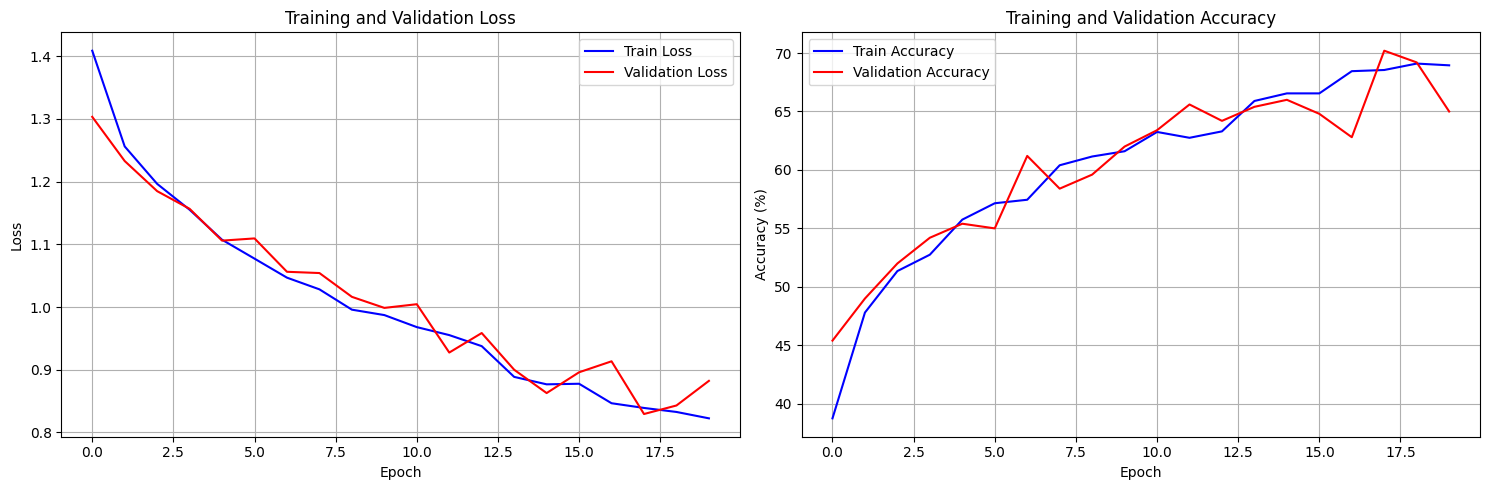

In [22]:
plot_training_history(history)

<i>Замечание</i>: чекпоинт переименован в MyTinyConvNet.pth

## Часть 2. Базовая U-Net на "Луне"

- Требования к архитектуре U-Net (зафиксируйте и опишите в отчёте):
    - Глубина: 4 уровня down/4 up (энкодер-декодер с skip-связями).
    - Базовые каналы на первом уровне: 32 или 64 (по желанию можно выбрать свое количество каналов, но надо будет объяснить).
    - Даунсемплинг: stride 2 или MaxPool.
    - Итоговый слой: 1 канал с сигмоидой (бинарная сегментация).
    - Ограничение на количество параметров: до ~2.5M (рекомендуется укладываться, но допускается ±10%).
    - Вход: 128×128×3.
- Обучение:
    - Лосс: BCEWithLogitsLoss или Dice Loss, допустимо комбинировать (например, 0.5BCE + 0.5Dice).
    - Метрики для мониторинга: IoU (Jaccard), Dice, Pixel Accuracy.
    - Аугментации: горизонтальные/вертикальные флипы, лёгкие геометрические и цветовые — по желанию (можно добавлять другие).
- Что сдаём по части 2:
    - Логи обучения и итоговые метрики на валидации: IoU, Dice, Pixel Acc.
    - 3–5 визуализаций: вход, предсказанная маска, GT маска.

Сделаем задание по аналогии с семинаром.


In [23]:
# дополнительная загрузка библиотек
import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [ ]:
class MoonSegmentationDataset(Dataset):

    def __init__(self, root_dir, image_folder='render', mask_folder='ground', 
                 image_ids=None, augmentation=None, preprocessing=None):
        self.root_dir = root_dir
        self.image_folder = image_folder
        self.mask_folder = mask_folder
        self.augmentation = augmentation
        self.preprocessing = preprocessing
        
        images_dir = os.path.join(root_dir, 'images', image_folder)
        masks_dir = os.path.join(root_dir, 'images', mask_folder)
        
        if image_ids is None:
            all_images = os.listdir(images_dir)
            self.image_ids = [img.replace('.png', '') for img in all_images if img.endswith('.png')]
        else:
            self.image_ids = image_ids
        
    
    def __len__(self):
        return len(self.image_ids)
    
    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        
        image_path = os.path.join(self.root_dir, 'images', self.image_folder, f"{image_id}.png")
        
        # Для масок убираем префикс "render" если он есть
        # Например: render0001 - 0001
        mask_id = image_id.replace('render', '') if 'render' in image_id else image_id
        mask_path = os.path.join(self.root_dir, 'images', self.mask_folder, f"ground{mask_id}.png")
        
        image = cv2.imread(image_path)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Нормализуем бинарную маску к [0, 1]
        # 0 = фон, 1 = камни
        mask = (mask > 0).astype(np.float32)
        
        # Применяем аугментации
        if self.augmentation:
            sample = self.augmentation(image=image, mask=mask)
            image, mask = sample['image'], sample['mask']
        
        # Применяем предобработку
        if self.preprocessing:
            sample = self.preprocessing(image=image, mask=mask)
            image, mask = sample['image'], sample['mask']
        
        return image, mask

In [31]:
# Аугментации для обучения
train_augmentation = A.Compose([
    A.Resize(128, 128), # по условиям задания
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.OneOf([
        A.GaussNoise(),
        A.GaussianBlur(blur_limit=(3, 7)),
        A.MedianBlur(blur_limit=5),
    ], p=0.3),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
])

preprocessing = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_augmentation = A.Compose([
    A.Resize(128, 128), # по условиям задания
])

In [34]:
# разделение данных на train и валидацию
root_dir = "MOON_SEGMENTATION_BINARY"

images_dir = os.path.join(root_dir, 'images', 'render')
all_images = [img.replace('.png', '') for img in os.listdir(images_dir) if img.endswith('.png')][:100]

print(f"Всего изображений: {len(all_images)}")

train_ids, val_ids = train_test_split(all_images, test_size=0.2, random_state=42)

print(f"Train: {len(train_ids)} изображений")
print(f"Val: {len(val_ids)} изображений")

train_dataset = MoonSegmentationDataset(
    root_dir=root_dir,
    image_folder='render',
    mask_folder='ground',
    image_ids=train_ids,
    augmentation=train_augmentation,
    preprocessing=preprocessing
)

val_dataset = MoonSegmentationDataset(
    root_dir=root_dir,
    image_folder='render',
    mask_folder='ground',
    image_ids=val_ids,
    augmentation=val_augmentation,
    preprocessing=preprocessing
)

BATCH_SIZE = 4
NUM_WORKERS = 0

train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=NUM_WORKERS,
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=NUM_WORKERS,
)

print(f"Батчей в train: {len(train_loader)}")
print(f"Батчей в val: {len(val_loader)}")

Всего изображений: 100
Train: 80 изображений
Val: 20 изображений
Батчей в train: 20
Батчей в val: 5


Размер батча изображений: torch.Size([4, 3, 128, 128])
Размер батча масок: torch.Size([4, 128, 128])


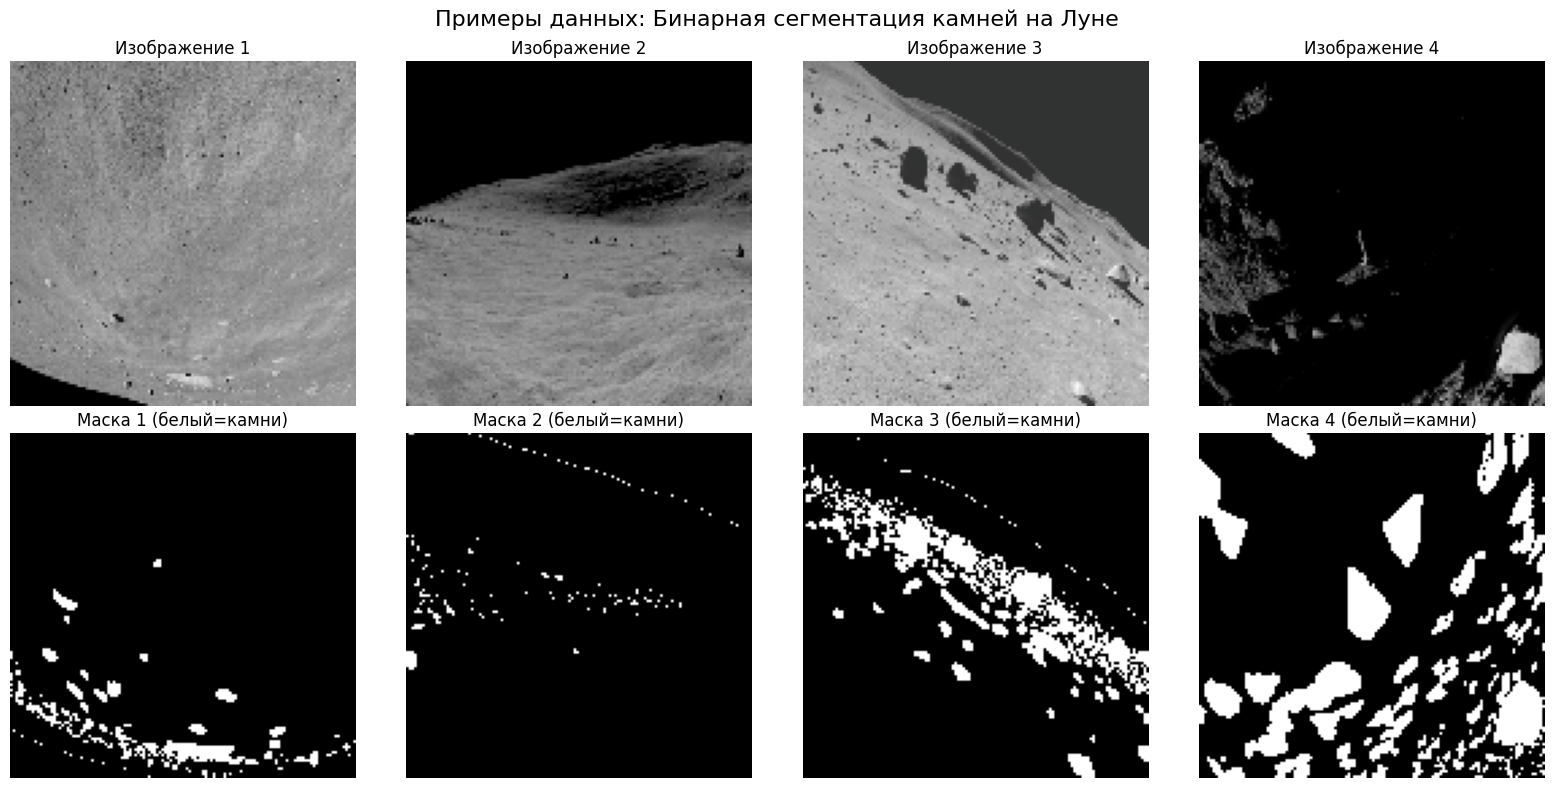

In [35]:
# визуализация датасета - изображений и их масок сегментации
def denormalize(img_tensor):
    """Денормализация изображения для визуализации"""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img_tensor * std + mean
    return img.clamp(0, 1)

images, masks = next(iter(train_loader))

print(f"Размер батча изображений: {images.shape}")
print(f"Размер батча масок: {masks.shape}")

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i in range(min(4, len(images))):
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    mask = masks[i].numpy()
    
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"Изображение {i+1}")
    axes[0, i].axis('off')
    
    axes[1, i].imshow(mask, cmap='gray')
    axes[1, i].set_title(f"Маска {i+1} (белый=камни)")
    axes[1, i].axis('off')

plt.suptitle("Примеры данных: Бинарная сегментация камней на Луне", fontsize=16)
plt.tight_layout()
plt.show()

Теперь, реализуем базовую U-Net архитектуру. Она будет иметь следующую структуру:

| Уровень      | Вход       | Выход      | Описание                            |
| ------------ | ---------- | ---------- | ----------------------------------- |
| enc1         | 128×128×3  | 128×128×32 | DoubleConv                          |
| enc2         | 128×128×32 | 64×64×64   | DoubleConv + MaxPool                |
| enc3         | 64×64×64   | 32×32×128  | DoubleConv + MaxPool                |
| enc4         | 32×32×128  | 16×16×256  | DoubleConv + MaxPool                |
| bottom       | 16×16×256  | 8×8×256    | MaxPool                             |
| upconv1+dec1 | 8×8×256    | 16×16×128  | ConvTranspose + concat + DoubleConv |
| upconv2+dec2 | 16×16×128  | 32×32×64   | ConvTranspose + concat + DoubleConv |
| upconv3+dec3 | 32×32×64   | 64×64×32   | ConvTranspose + concat + DoubleConv |
| upconv4+dec4 | 64×64×32   | 128×128×1  | ConvTranspose + concat + DoubleConv |



In [53]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(UNet, self).__init__()
        self.pool = nn.MaxPool2d(2)

        # Энкодер
        self.enc1 = DoubleConv(in_channels, 32)
        self.enc2 = DoubleConv(32, 64)
        self.enc3 = DoubleConv(64, 128)
        self.enc4 = DoubleConv(128, 256)

        # Адаптация входа
        self.conv_adapt = nn.Conv2d(in_channels, 16, kernel_size=1)

        # Декодер
        self.upconv1 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(128 + 256, 128)  

        self.upconv2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(64 + 128, 64)   

        self.upconv3 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(32 + 64, 32)    

        self.upconv4 = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(16 + 16, out_channels)  

    def forward(self, x):
        x0 = x
        x1 = self.enc1(x0)
        x2 = self.enc2(self.pool(x1))
        x3 = self.enc3(self.pool(x2))
        x4 = self.enc4(self.pool(x3))
        x_bottom = self.pool(x4)

        u1 = self.upconv1(x_bottom)
        u1 = torch.cat([u1, x4], dim=1)
        u1 = self.dec1(u1)

        u2 = self.upconv2(u1)
        u2 = torch.cat([u2, x3], dim=1)
        u2 = self.dec2(u2)

        u3 = self.upconv3(u2)
        u3 = torch.cat([u3, x2], dim=1)
        u3 = self.dec3(u3)

        u4 = self.upconv4(u3)
        u4 = torch.cat([u4, self.conv_adapt(x0)], dim=1)
        output = self.dec4(u4)

        return output  # один выходной тензор [B,1,H,W]

# Проверка
if __name__ == "__main__":
    model = UNet()
    x = torch.randn(1, 3, 128, 128)
    output = model(x)
    print(f"Выход: {output.shape}")
    print(f"Количество параметров: {sum(p.numel() for p in model.parameters()):,}")

Выход: torch.Size([1, 1, 128, 128])
Количество параметров: 2,124,351


Реализуем функции потерь и метрики для обучения модели. Будем использовать комбинированный лосс $0.5 \cdot BCE + 0.5 \cdot Dice$.

In [ ]:
# Метрики для монитоинга
def dice_coef(pred, target, smooth=1e-6):
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum(dim=(1,2,3))
    union = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3))
    dice = (2. * intersection + smooth) / (union + smooth)
    return dice.mean().item()

def iou_score(pred, target, smooth=1e-6):
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum(dim=(1,2,3))
    union = (pred + target - pred * target).sum(dim=(1,2,3))
    iou = (intersection + smooth) / (union + smooth)
    return iou.mean().item()

def pixel_accuracy(pred, target):
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()
    correct = (pred == target).float().sum()
    total = target.numel()
    return (correct / total).item()

# Dice Loss 
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        pred = torch.sigmoid(logits)
        intersection = (pred * targets).sum(dim=(1,2,3))
        union = pred.sum(dim=(1,2,3)) + targets.sum(dim=(1,2,3))
        dice_loss = 1 - (2. * intersection + self.smooth) / (union + self.smooth)
        return dice_loss.mean()

# Функция обучения 
def train_unet(model, train_loader, val_loader, optimizer, device, 
               num_epochs=50, save_path="best_model.pth", bce_weight=0.5, dice_weight=0.5):
    
    bce_loss_fn = nn.BCEWithLogitsLoss()
    dice_loss_fn = DiceLoss()
    
    best_val_dice = 0.0
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_dice": [],
        "val_iou": [],
        "val_acc": []
    }
    
    for epoch in range(1, num_epochs+1):
        model.train()
        train_loss = 0.0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs} [Train]")
        
        for images, masks in pbar:
            images = images.to(device)
            masks = masks.to(device).unsqueeze(1)  
    
            optimizer.zero_grad()
            outputs = model(images)
    
            # Комбинированный лосс 0.5 BCE + 0.5 Dice
            loss = bce_weight * bce_loss_fn(outputs, masks) + dice_weight * dice_loss_fn(outputs, masks)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            pbar.set_postfix({"Loss": train_loss / (pbar.n+1)})
        
        avg_train_loss = train_loss / len(train_loader)
        history["train_loss"].append(avg_train_loss)
        
        # Валидация 
        model.eval()
        val_loss = 0.0
        val_dice = 0.0
        val_iou = 0.0
        val_acc = 0.0
        with torch.no_grad():
            for images, masks in val_loader:
                images = images.to(device)
                masks = masks.to(device).unsqueeze(1)  
                outputs = model(images)
                loss = bce_weight * bce_loss_fn(outputs, masks) + dice_weight * dice_loss_fn(outputs, masks)
                val_loss += loss.item()
                
                val_dice += dice_coef(outputs, masks)
                val_iou += iou_score(outputs, masks)
                val_acc += pixel_accuracy(outputs, masks)
        
        n_val = len(val_loader)
        val_loss /= n_val
        val_dice /= n_val
        val_iou /= n_val
        val_acc /= n_val
        
        history["val_loss"].append(val_loss)
        history["val_dice"].append(val_dice)
        history["val_iou"].append(val_iou)
        history["val_acc"].append(val_acc)
        
        print(f"\nEpoch {epoch}: Train Loss={avg_train_loss:.4f} | "
              f"Val Loss={val_loss:.4f} | Dice={val_dice:.4f} | IoU={val_iou:.4f} | Acc={val_acc:.4f}")
        
        # Сохраняем лучшую модель 
        if val_dice > best_val_dice:
            best_val_dice = val_dice
            torch.save(model.state_dict(), save_path)
            print(f"Сохраняем лучшую модель в файле {save_path}! Dice = {best_val_dice:.4f}\n")
    
    return history


In [60]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

history = train_unet(model, train_loader, val_loader, optimizer, device, num_epochs = 20)

Epoch 1/20 [Train]: 100%|██████████| 20/20 [00:07<00:00,  2.67it/s, Loss=0.799]



Epoch 1: Train Loss=0.7985 | Val Loss=0.7802 | Dice=0.1403 | IoU=0.0785 | Acc=0.7554
Сохраняем лучшую модель в файле best_model.pth! Dice = 0.1403



Epoch 2/20 [Train]: 100%|██████████| 20/20 [00:07<00:00,  2.51it/s, Loss=0.783]



Epoch 2: Train Loss=0.7831 | Val Loss=0.7881 | Dice=0.2008 | IoU=0.1153 | Acc=0.8654
Сохраняем лучшую модель в файле best_model.pth! Dice = 0.2008



Epoch 3/20 [Train]: 100%|██████████| 20/20 [00:08<00:00,  2.46it/s, Loss=0.775]


...


Epoch 18: Train Loss=0.7643 | Val Loss=0.7722 | Dice=0.2832 | IoU=0.1733 | Acc=0.9144


Epoch 19/20 [Train]: 100%|██████████| 20/20 [00:10<00:00,  1.84it/s, Loss=0.764]



Epoch 19: Train Loss=0.7640 | Val Loss=0.7709 | Dice=0.2994 | IoU=0.1861 | Acc=0.9174
Сохраняем лучшую модель в файле best_model.pth! Dice = 0.2994



Epoch 20/20 [Train]: 100%|██████████| 20/20 [00:10<00:00,  1.99it/s, Loss=0.761]



Epoch 20: Train Loss=0.7614 | Val Loss=0.7705 | Dice=0.3109 | IoU=0.1959 | Acc=0.9113
Сохраняем лучшую модель в файле best_model.pth! Dice = 0.3109



In [93]:
def plot_training_history_subplots(history):
    """
    Визуализация метрик обучения.
    """
    
    df = pd.DataFrame(history)
    df["epoch"] = range(1, len(df) + 1)
    df = df.round(3)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Train и Validation Loss 
    axes[0,0].plot(df["epoch"], df["train_loss"], label="Train Loss", marker="o")
    axes[0,0].plot(df["epoch"], df["val_loss"], label="Val Loss", marker="o")
    axes[0,0].set_title("Loss")
    axes[0,0].set_xlabel("Epoch")
    axes[0,0].set_ylabel("Loss")
    axes[0,0].grid(True)
    axes[0,0].legend()

    # Dice 
    axes[0,1].plot(df["epoch"], df["val_dice"], label="Dice", marker="o", color="purple")
    axes[0,1].set_title("Dice Score")
    axes[0,1].set_xlabel("Epoch")
    axes[0,1].set_ylabel("Dice")
    axes[0,1].grid(True)
    axes[0,1].legend()

    # IoU 
    axes[1,0].plot(df["epoch"], df["val_iou"], label="IoU", marker="o", color="green")
    axes[1,0].set_title("IoU Score")
    axes[1,0].set_xlabel("Epoch")
    axes[1,0].set_ylabel("IoU")
    axes[1,0].grid(True)
    axes[1,0].legend()

    # Pixel Accuracy 
    axes[1,1].plot(df["epoch"], df["val_acc"], label="Pixel Accuracy", marker="o", color="orange")
    axes[1,1].set_title("Pixel Accuracy")
    axes[1,1].set_xlabel("Epoch")
    axes[1,1].set_ylabel("Accuracy")
    axes[1,1].grid(True)
    axes[1,1].legend()

    plt.tight_layout()
    plt.show()
    


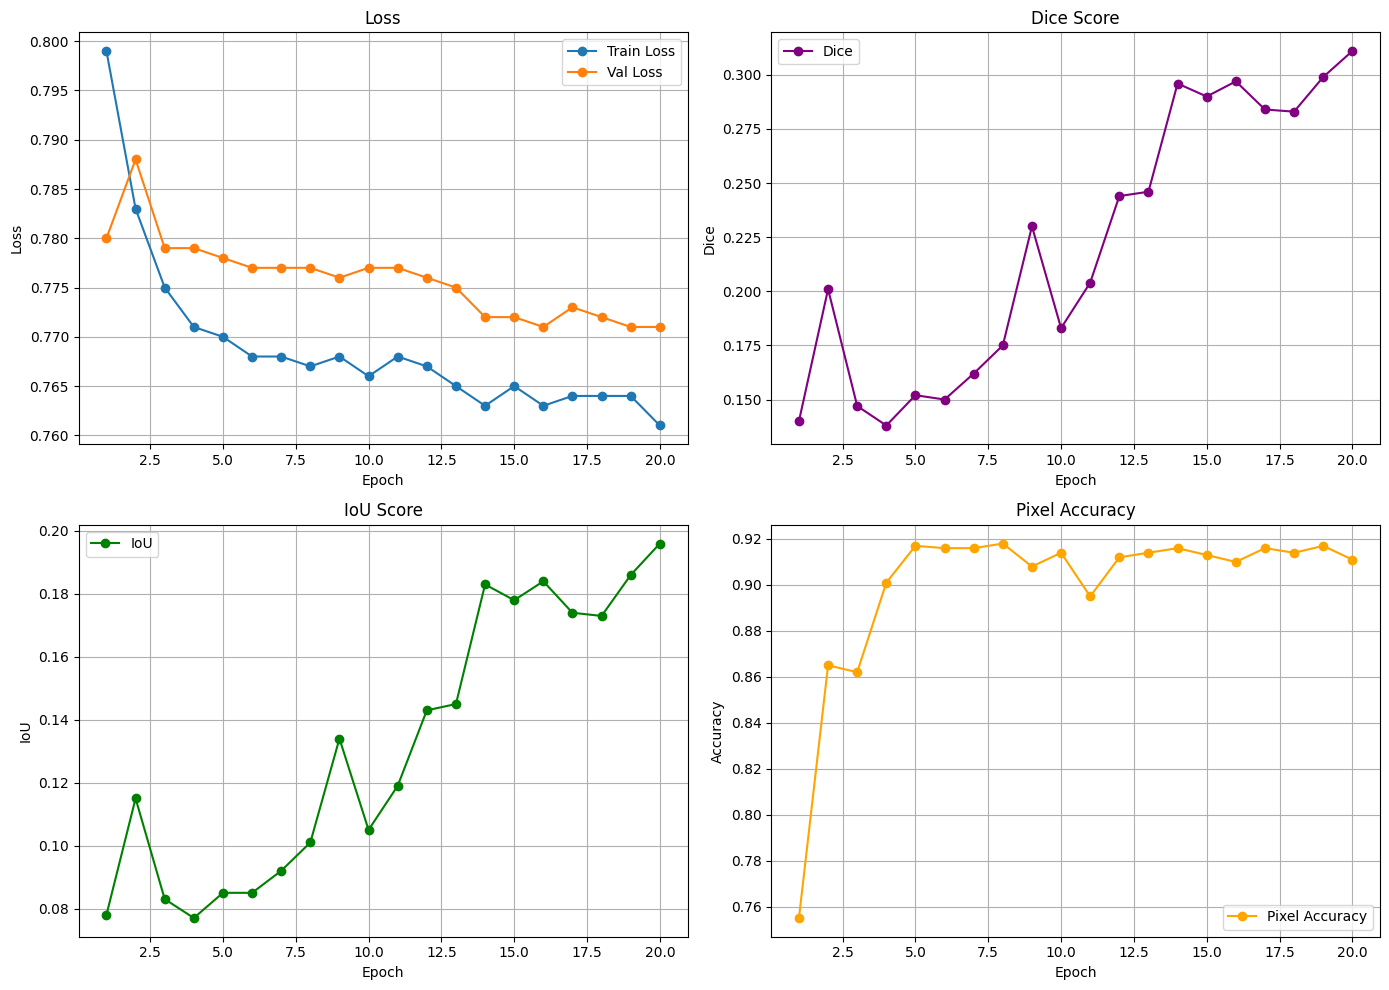

In [94]:
plot_training_history_subplots(history)

In [98]:
print('Итоговые значения метрик:')
for k, v in zip(history.keys(), history.values()):
    print(f'{k} = {v[len(v)-1]:.3f}')

Итоговые значения метрик:
train_loss = 0.761
val_loss = 0.771
val_dice = 0.311
val_iou = 0.196
val_acc = 0.911


In [86]:
# визуализация работы модели
def visualize_predictions(model, dataloader, device, num_samples=5):
    model.eval()
    shown = 0

    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device)
            masks = masks.to(device).unsqueeze(1)

            outputs = model(images)
            preds = (torch.sigmoid(outputs) > 0.5).float()

            for i in range(images.size(0)):
                img = denormalize(images[i]).cpu().permute(1, 2, 0).numpy()
                gt_mask = masks[i].cpu().squeeze().numpy()
                pred_mask = preds[i].cpu().squeeze().numpy()

                fig, axes = plt.subplots(1, 3, figsize=(12, 4))

                axes[0].imshow(img)
                axes[0].set_title("Входное изображение")
                axes[0].axis("off")

                axes[1].imshow(pred_mask, cmap="gray")
                axes[1].set_title("Предсказанная маска")
                axes[1].axis("off")

                axes[2].imshow(gt_mask, cmap="gray")
                axes[2].set_title("Ground Truth Маска")
                axes[2].axis("off")

                plt.tight_layout()
                plt.show()

                plt.close(fig)

                shown += 1
                if shown >= num_samples:
                    return


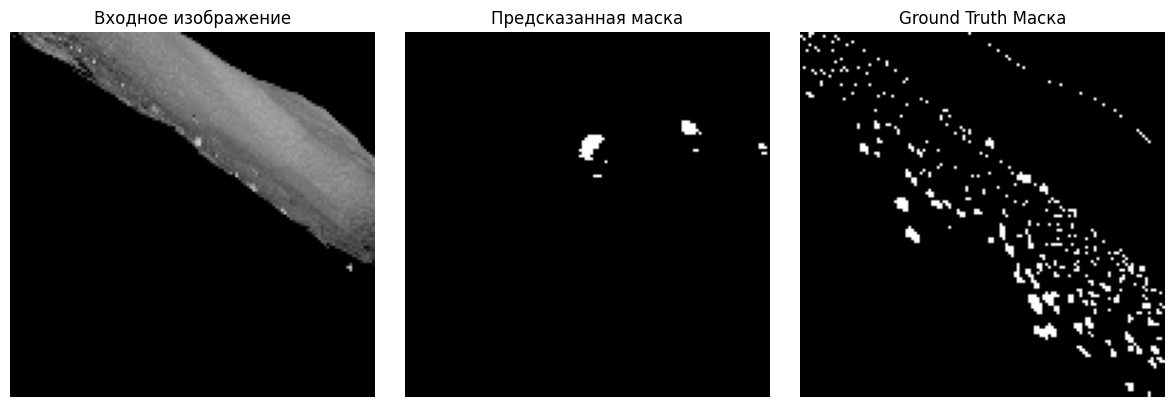

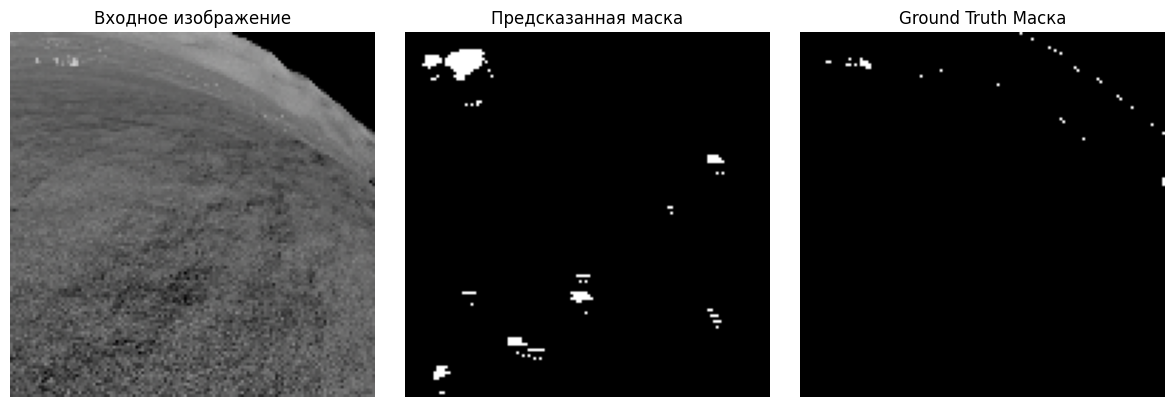

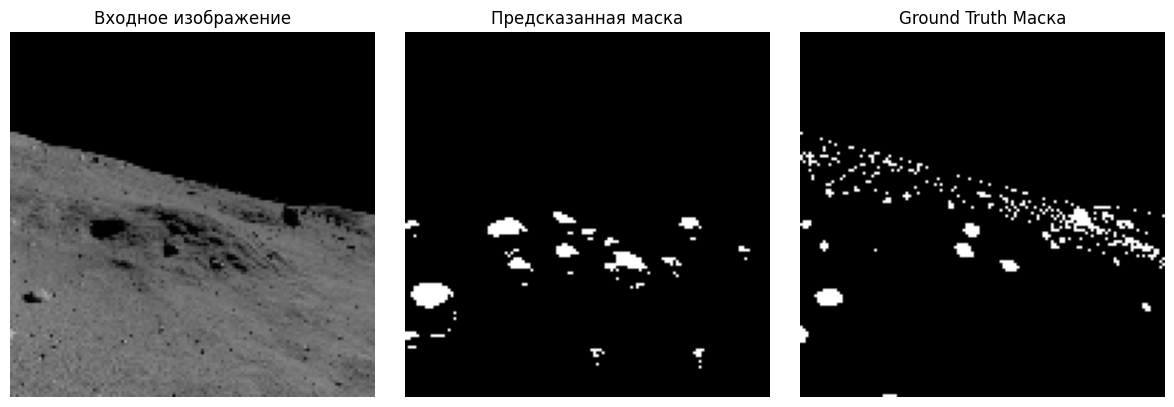

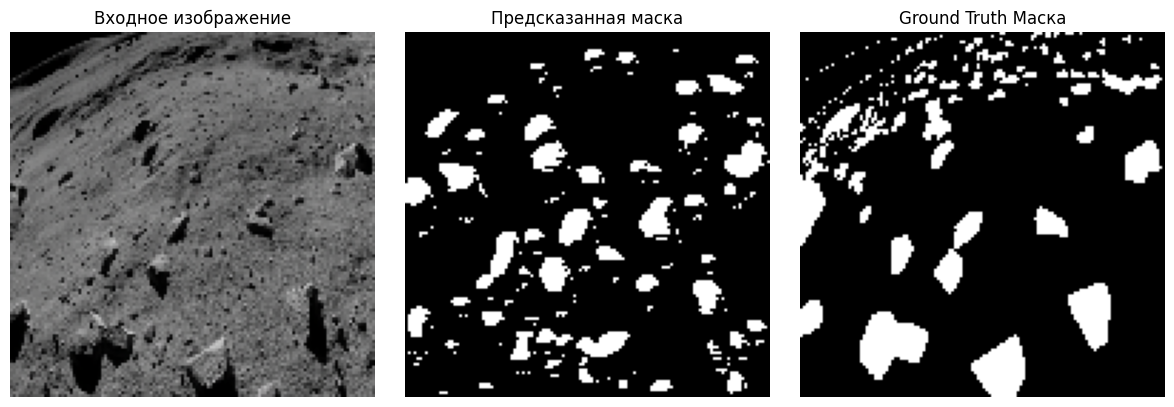

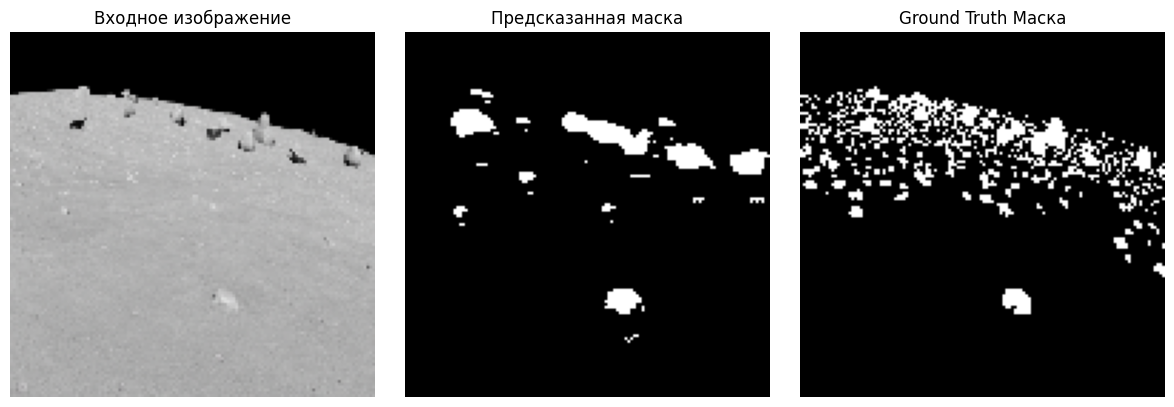

In [87]:
visualize_predictions(model, val_loader, device, num_samples = 5)

## Часть 3. U-Net с бэкбоном из классификатора

- Идея: использовать энкодер из вашей модели классификации как бэкбон U‑Net.
    - Вариант A (заморозка): заморозить веса энкодера, обучать только декодер.
    - Вариант B (тонкая настройка): полностью разморозить энкодер на поздних этапах.
    - Если у классификатора есть GAP/FC-голова — удалите её; возьмите сверточные блоки до глобального усреднения как энкодерные стадии.
- Ограничения и замечания:
    - Если количество стадий не совпадает, добавьте адаптационные 1×1 свёртки и интерполяции/пулинг, но опишите это.
- Обучение:
    - Тот же датасет "луна", те же метрики.
    - Сравните результаты с базовой U‑Net из части 2 (таблица метрик).
- Что сдаём по части 3:
    - Метрики и сравнение с базовой U‑Net (желательно таблица).


### Вариант А

In [ ]:
# ConvBlock из классификатора 
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, down=False):
        super().__init__()
        stride = 2 if down else 1
        self.conv = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.bn(self.conv(x)))


# MyTinyConvNet — используем только features 
class MyTinyConvNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3, 64),                  
            ConvBlock(64, 128, down=True),     
            ConvBlock(128, 128),

            ConvBlock(128, 256, down=True),    
            ConvBlock(256, 256),

            ConvBlock(256, 512, down=True),   
            ConvBlock(512, 512),
        )

    def forward(self, x):
        return self.features(x)


# DoubleConv из базового UNet 
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.net(x)


# U-Net вариант А
class UNetTinyBackbone(nn.Module):
    def __init__(self, out_channels=1, freeze_encoder=False):
        super().__init__()

        base = MyTinyConvNet().features  

        self.enc1 = nn.Sequential(base[0])
        self.enc2 = nn.Sequential(base[1], base[2])
        self.enc3 = nn.Sequential(base[3], base[4])
        self.enc4 = nn.Sequential(base[5], base[6])

        if freeze_encoder:
            for p in self.enc1.parameters(): p.requires_grad = False
            for p in self.enc2.parameters(): p.requires_grad = False
            for p in self.enc3.parameters(): p.requires_grad = False
            for p in self.enc4.parameters(): p.requires_grad = False

        # decoder mirror
        self.up1 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.dec1 = DoubleConv(256+256, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.dec2 = DoubleConv(128+128, 128)

        self.up3 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.dec3 = DoubleConv(64+64, 64)

        self.out_conv = nn.Conv2d(64, out_channels, 1)

    # Метод для загрузки чекпоинта от классификатора
    def load_backbone_weights(self, checkpoint_path):
        ckpt = torch.load(checkpoint_path, map_location="cpu")

        own = self.state_dict()
        loaded = 0

        for k, v in ckpt.items():
            # ищем только энкодерные ключи
            if "features" in k:  
                # сопоставляем ключи MyTinyConvNet.features блоками энкодера
                new_key = k.replace("features.0", "enc1.0") \
                           .replace("features.1", "enc2.0") \
                           .replace("features.2", "enc2.1") \
                           .replace("features.3", "enc3.0") \
                           .replace("features.4", "enc3.1") \
                           .replace("features.5", "enc4.0") \
                           .replace("features.6", "enc4.1")

                if new_key in own and own[new_key].shape == v.shape:
                    own[new_key] = v
                    loaded += 1

        self.load_state_dict(own)
        print(f"Loaded {loaded} encoder parameters from checkpoint.")

    def forward(self, x):
        x1 = self.enc1(x)     
        x2 = self.enc2(x1)    
        x3 = self.enc3(x2)     
        x4 = self.enc4(x3)    

        u1 = self.up1(x4)                
        u1 = torch.cat([u1, x3], dim=1)
        u1 = self.dec1(u1)

        u2 = self.up2(u1)                
        u2 = torch.cat([u2, x2], dim=1)
        u2 = self.dec2(u2)

        u3 = self.up3(u2)                 
        u3 = torch.cat([u3, x1], dim=1)
        u3 = self.dec3(u3)

        out = self.out_conv(u3)

        return out

# Проверка
if __name__ == "__main__":
    model = UNetTinyBackbone(out_channels=1)
    x = torch.randn(1, 3, 128, 128)
    y = model(x)
    print("Выход:", y.shape)
    print("Количество параметров:", sum(p.numel() for p in model.parameters()))


Выход: torch.Size([1, 1, 128, 128])
Количество параметров: 7664065


In [106]:
checkpoint_path = 'MyTinyConvNet.pth'
model = UNetTinyBackbone(out_channels=1, freeze_encoder=True).to(device)
model.load_backbone_weights(checkpoint_path)

model = UNetTinyBackbone(out_channels=1, freeze_encoder=False).to(device)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3
)

history_A = train_unet(model, train_loader, val_loader, optimizer, device, num_epochs = 20)

Loaded 42 encoder parameters from checkpoint.


Epoch 1/20 [Train]: 100%|██████████| 20/20 [00:50<00:00,  2.53s/it, Loss=0.694]



Epoch 1: Train Loss=0.6938 | Val Loss=0.7934 | Dice=0.0727 | IoU=0.0394 | Acc=0.6941
Сохраняем лучшую модель в файле best_model.pth! Dice = 0.0727



Epoch 2/20 [Train]: 100%|██████████| 20/20 [00:39<00:00,  1.98s/it, Loss=0.612]



Epoch 2: Train Loss=0.6120 | Val Loss=0.5700 | Dice=0.2839 | IoU=0.1753 | Acc=0.8989
Сохраняем лучшую модель в файле best_model.pth! Dice = 0.2839



...


Epoch 18: Train Loss=0.4996 | Val Loss=0.4750 | Dice=0.3870 | IoU=0.2551 | Acc=0.9020
Сохраняем лучшую модель в файле best_model.pth! Dice = 0.3870



Epoch 19/20 [Train]: 100%|██████████| 20/20 [00:35<00:00,  1.77s/it, Loss=0.518]



Epoch 19: Train Loss=0.5184 | Val Loss=0.4565 | Dice=0.3781 | IoU=0.2506 | Acc=0.9245


Epoch 20/20 [Train]: 100%|██████████| 20/20 [00:35<00:00,  1.79s/it, Loss=0.53] 



Epoch 20: Train Loss=0.5295 | Val Loss=0.4712 | Dice=0.3671 | IoU=0.2432 | Acc=0.9240


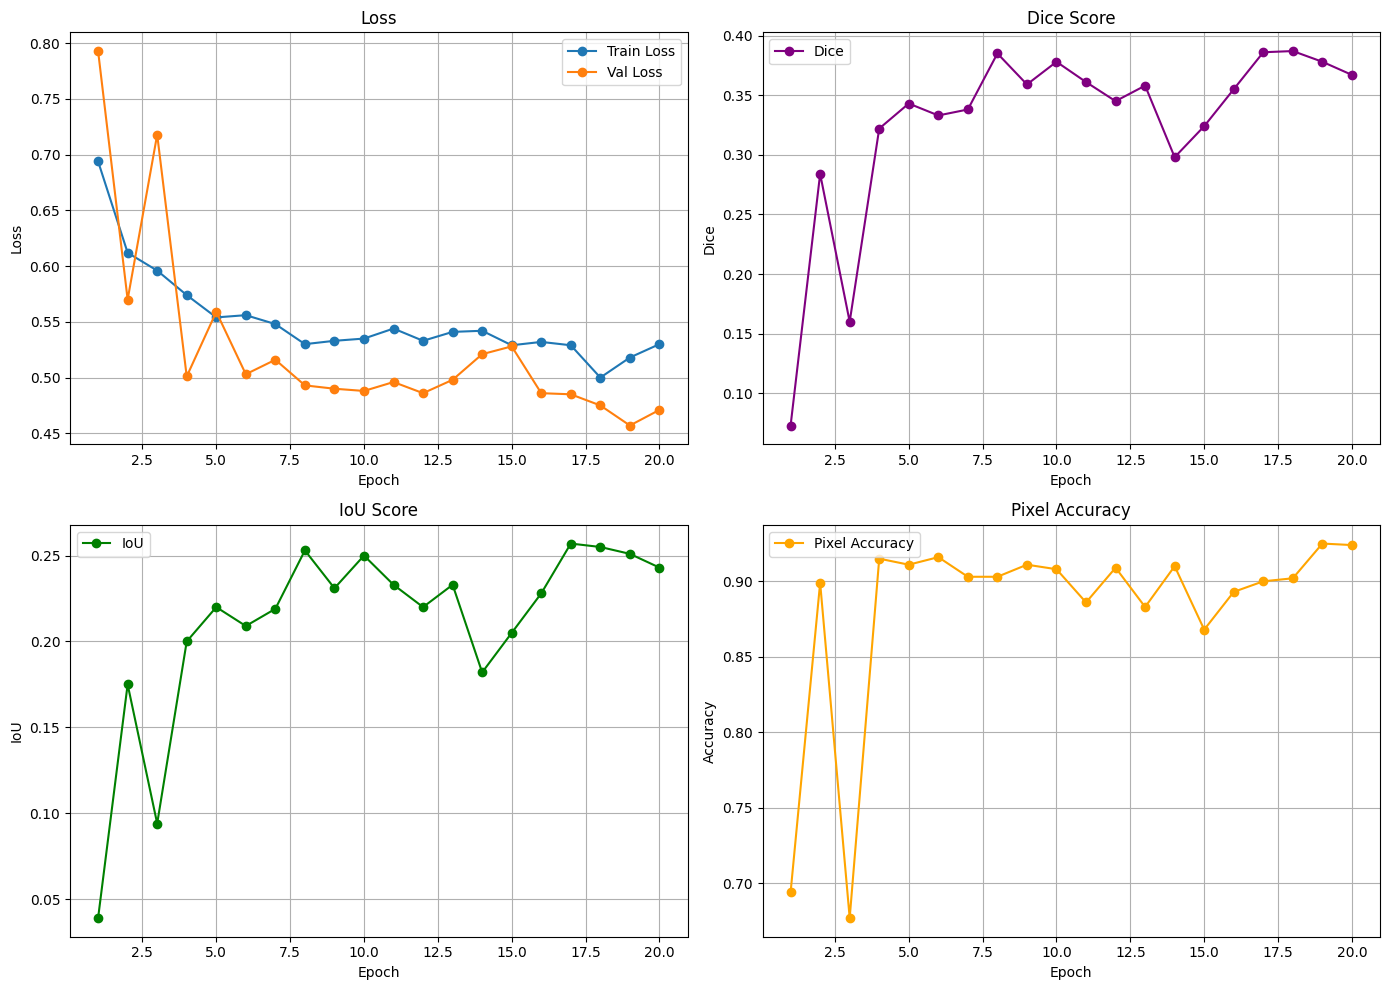

In [111]:
# визуализация метрик обучения
plot_training_history_subplots(history_A)

In [112]:
print('Итоговые значения метрик:')
for k, v in zip(history_A.keys(), history_A.values()):
    print(f'{k} = {v[len(v)-1]:.3f}')

Итоговые значения метрик:
train_loss = 0.530
val_loss = 0.471
val_dice = 0.367
val_iou = 0.243
val_acc = 0.924


### Вариант В

Обучение проведем в 2-х этапах:
1. сначала на 10 эпох обучим только декодер
2. после чего разморозим энкодер и дополнительно обучим модель

In [ ]:
checkpoint_path = 'MyTinyConvNet.pth'
model = UNetTinyBackbone(out_channels=1, freeze_encoder=True).to(device)
model.load_backbone_weights(checkpoint_path)

# Этап 1
optimizer_stage1 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3
)

history_Bstage1 = train_unet(
    model = model,
    train_loader = train_loader,
    val_loader = val_loader,
    optimizer = optimizer_stage1,
    device = device,
    num_epochs = 10,           
    save_path="stage1.pth",
    bce_weight=0.5,
    dice_weight=0.5
)

# Этап 2
for p in model.enc1.parameters(): p.requires_grad = True
for p in model.enc2.parameters(): p.requires_grad = True
for p in model.enc3.parameters(): p.requires_grad = True
for p in model.enc4.parameters(): p.requires_grad = True

# Оптимизатор для полной модели
optimizer_stage2 = torch.optim.Adam([
    {"params": model.enc1.parameters(), "lr": 1e-5},
    {"params": model.enc2.parameters(), "lr": 1e-5},
    {"params": model.enc3.parameters(), "lr": 1e-5},
    {"params": model.enc4.parameters(), "lr": 1e-5},

    {"params": model.up1.parameters(), "lr": 1e-4},
    {"params": model.up2.parameters(), "lr": 1e-4},
    {"params": model.up3.parameters(), "lr": 1e-4},
    {"params": model.dec1.parameters(), "lr": 1e-4},
    {"params": model.dec2.parameters(), "lr": 1e-4},
    {"params": model.dec3.parameters(), "lr": 1e-4},
    {"params": model.out_conv.parameters(), "lr": 1e-4},
])

history_Bstage2 = train_unet(
    model = model,
    train_loader = train_loader,
    val_loader = val_loader,
    optimizer = optimizer_stage2,
    device = device,
    num_epochs = 10,            
    save_path = "stage2.pth",
    bce_weight = 0.5,
    dice_weight= 0.5
)

Loaded 42 encoder parameters from checkpoint.


Epoch 1/10 [Train]: 100%|██████████| 20/20 [00:31<00:00,  1.58s/it, Loss=0.714]



Epoch 1: Train Loss=0.7144 | Val Loss=0.6697 | Dice=0.2933 | IoU=0.1807 | Acc=0.8936
Сохраняем лучшую модель в файле stage1.pth! Dice = 0.2933



Epoch 2/10 [Train]: 100%|██████████| 20/20 [00:30<00:00,  1.50s/it, Loss=0.62] 



Epoch 2: Train Loss=0.6202 | Val Loss=0.5800 | Dice=0.3147 | IoU=0.1963 | Acc=0.9054
Сохраняем лучшую модель в файле stage1.pth! Dice = 0.3147



...


Epoch 8: Train Loss=0.5122 | Val Loss=0.4637 | Dice=0.3724 | IoU=0.2450 | Acc=0.9144


Epoch 9/10 [Train]: 100%|██████████| 20/20 [00:34<00:00,  1.73s/it, Loss=0.506]



Epoch 9: Train Loss=0.5058 | Val Loss=0.4730 | Dice=0.3792 | IoU=0.2502 | Acc=0.8954


Epoch 10/10 [Train]: 100%|██████████| 20/20 [00:34<00:00,  1.73s/it, Loss=0.492]



Epoch 10: Train Loss=0.4917 | Val Loss=0.4561 | Dice=0.3906 | IoU=0.2593 | Acc=0.9090
Сохраняем лучшую модель в файле stage2.pth! Dice = 0.3906



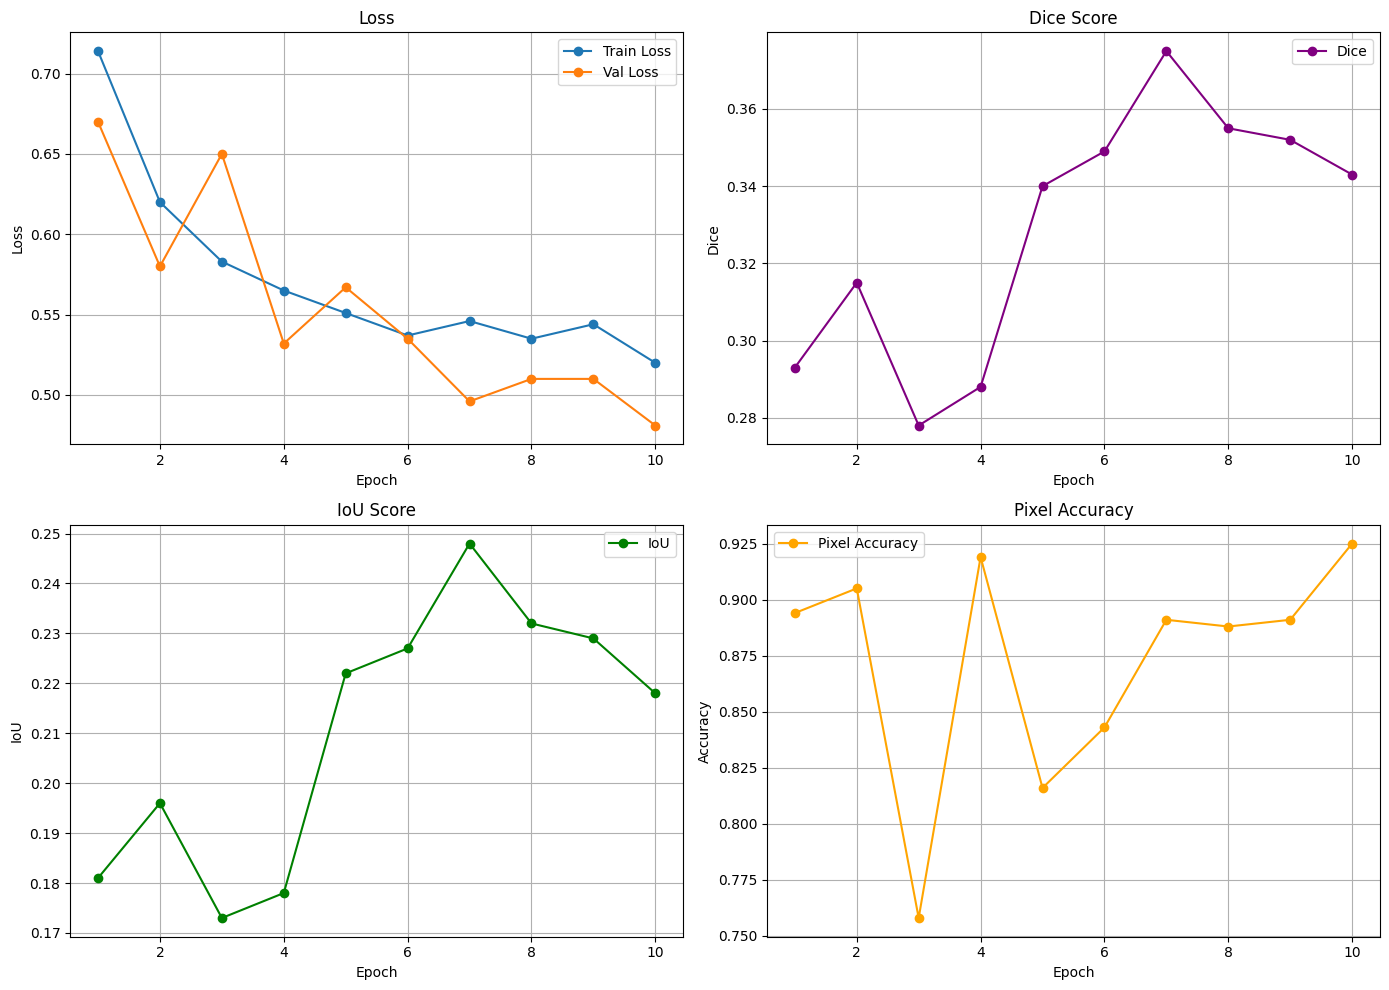

In [114]:
# визуализация метрик на этапе 1
plot_training_history_subplots(history_Bstage1)

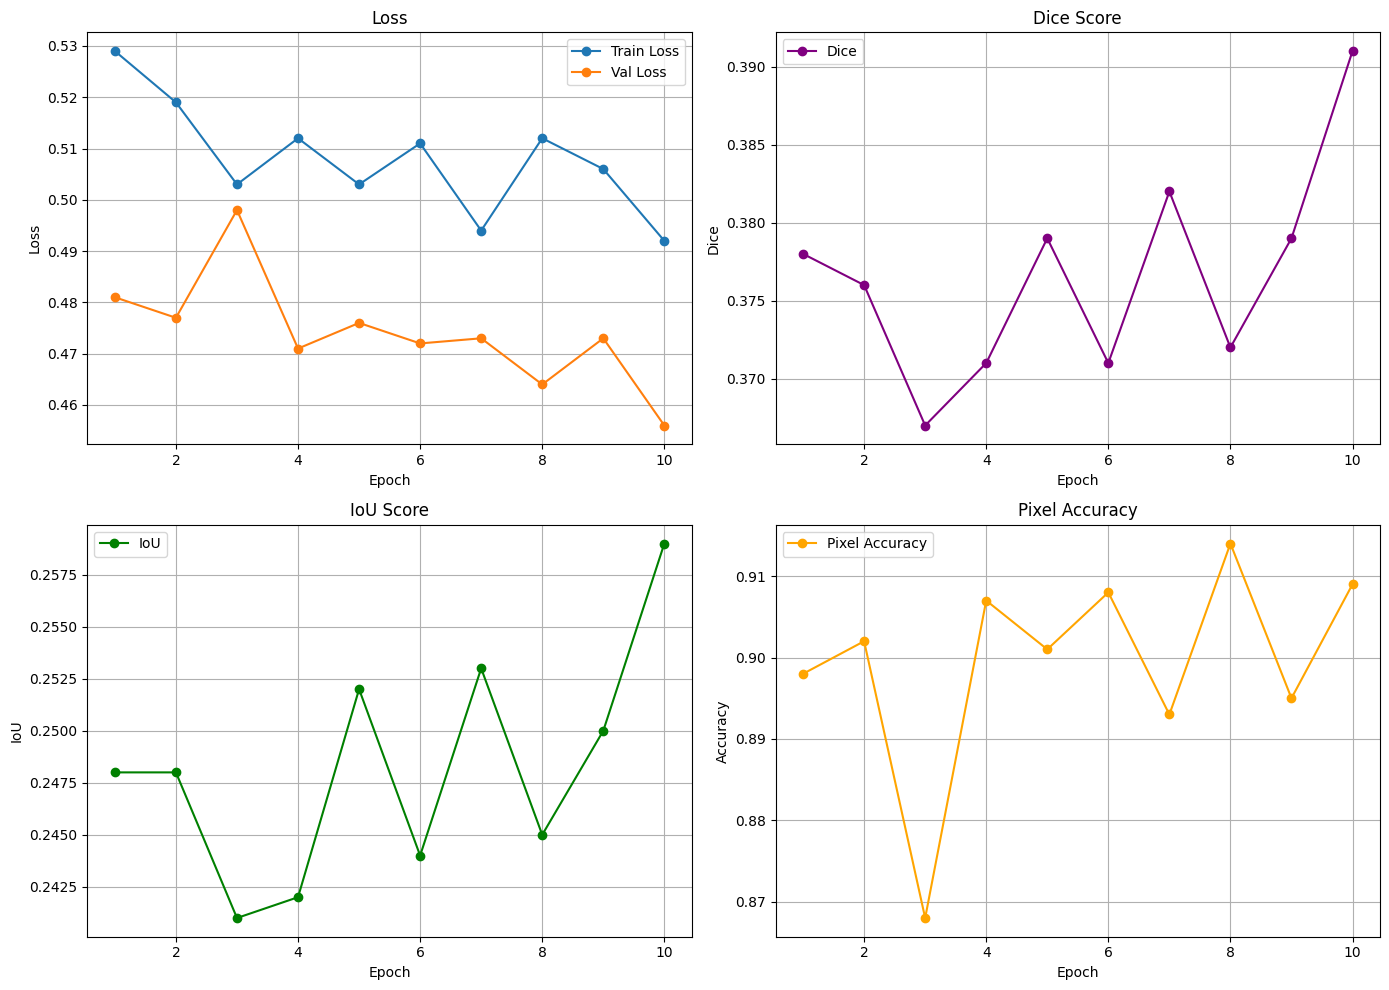

In [115]:
# визуализация метрик на этапе 2
plot_training_history_subplots(history_Bstage2)

In [116]:
# итоговые значения метрик
print('Итоговые значения метрик:')
for k, v in zip(history_Bstage2.keys(), history_Bstage2.values()):
    print(f'{k} = {v[len(v)-1]:.3f}')

Итоговые значения метрик:
train_loss = 0.492
val_loss = 0.456
val_dice = 0.391
val_iou = 0.259
val_acc = 0.909


#### Выводы

In [118]:
# таблица для сравнения результатов
res = [{'model' : 'Basic UNet',
        'train_loss': 0.761, 
        'val_loss': 0.771,
        'val_dice': 0.311,
        'val_iou' : 0.196,
        'val_acc' : 0.911},
       {'model' : 'Вариант А',
       'train_loss': 0.530, 
        'val_loss': 0.471,
        'val_dice': 0.367,
        'val_iou' : 0.243,
        'val_acc' : 0.924},
       {'model' : 'Вариант B',
        'train_loss': 0.492, 
        'val_loss': 0.456,
        'val_dice': 0.391,
        'val_iou' : 0.259,
        'val_acc' : 0.909}]

res = pd.DataFrame(res)
res

,model,train_loss,val_loss,val_dice,val_iou,val_acc
0,Basic UNet,0.761,0.771,0.311,0.196,0.911
1,Вариант А,0.530,0.471,0.367,0.243,0.924
2,Вариант B,0.492,0.456,0.391,0.259,0.909


На основе полученных результатов видим, что использование предобученного энкодера существенно улучшает качество сегментации: базовый UNet имеет низкие показатели Dice (0.311) и IoU (0.196), тогда как Вариант A с замороженным энкодером уже заметно лучше (Dice 0.367, IoU 0.243). Вариант А уступает Варианту В по метрикам Dice и IoU, но при этом у него accuracy немного выше (0.924, в то время как у варианта В 0.909). 

Взвешивая все метрики видим, что лучшей моделью является модель В.
